In [4]:
# CARGA DE DATOS #

import pandas as pd
import matplotlib.pyplot as plt
# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-001.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Ubicación',
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:272][desired_columns]

# Filtrar solo las filas donde Ubicación es "Puente Bilbao"
df = df[df['Ubicación'] == 'Puente Bilbao']

# Eliminar la columna "Ubicación"
df = df.drop(columns=['Ubicación'])

df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
12,10.4,0.87,13.9,8.2,1250,620,28,4.55,NaN,60.5,102,121
13,10.4,0.87,13.8,8.1,1220,600,28,4.47,NaN,118,102,121
22,18.2,0.77,15.3,7.8,1280,630,110,2.03,NaN,622,106,128
23,18.2,0.77,15.3,8,1290,630,110,1.94,NaN,397,106,126
32,14.4,0.4,15.6,8.3,1240,610,40,4.59,NaN,40.8,110,99
33,14.4,0.4,16.1,8.2,1240,610,40,4.32,NaN,44.8,106,99
42,18,0.6,17.75,7.9,1210,600,92,1.79,27.5,1000,114,97


In [5]:
#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

""" mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)
"""
#df_sin_nulos=df
df_sin_nulos.isna().sum()
#df_sin_nulos.head()
df_sin_nulos

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
42,18,0.6,17.75,7.9,1210,600,92,1.79,27.5,1000,114,97
43,18,0.6,18.05,7.7,1170,580,92,1.35,27.5,1000,114,95
52,14.3,0.54,21,8.1,1370,680,56,3.6,25,199,106,118
53,14.3,0.54,25.5,8.1,1400,690,56,1.87,25,220,110,120
72,13.4,0.56,16.8,8.1,1470,730,128,0.68,30,60.9,181,110
73,13.4,0.56,15.8,8.2,1460,720,128,0.73,30,53.4,181,110
82,23,0.36,21,7.3,1590,790,620,0,25,1000,228,118
83,23,0.36,20.8,7.3,1520,750,620,0,25,1000,228,118
92,15.2,0.52,17.4,8.1,1020,500,82,2.87,35,1000,135,64
93,15.2,0.52,17.3,8,960,470,82,1.82,35,1000,135,64


In [6]:
df_sin_nulos.describe()

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
count,32,32.00,32.0,32.0,32,32,32,32,32,32,32,32
unique,16,14.00,27.0,12.0,28,24,12,30,6,23,14,14
top,18,0.54,19.9,7.8,1460,520,56,0,30,1000,114,142
freq,2,4.00,2.0,8.0,3,3,4,2,14,8,4,6


#### Histogramas de datos reales

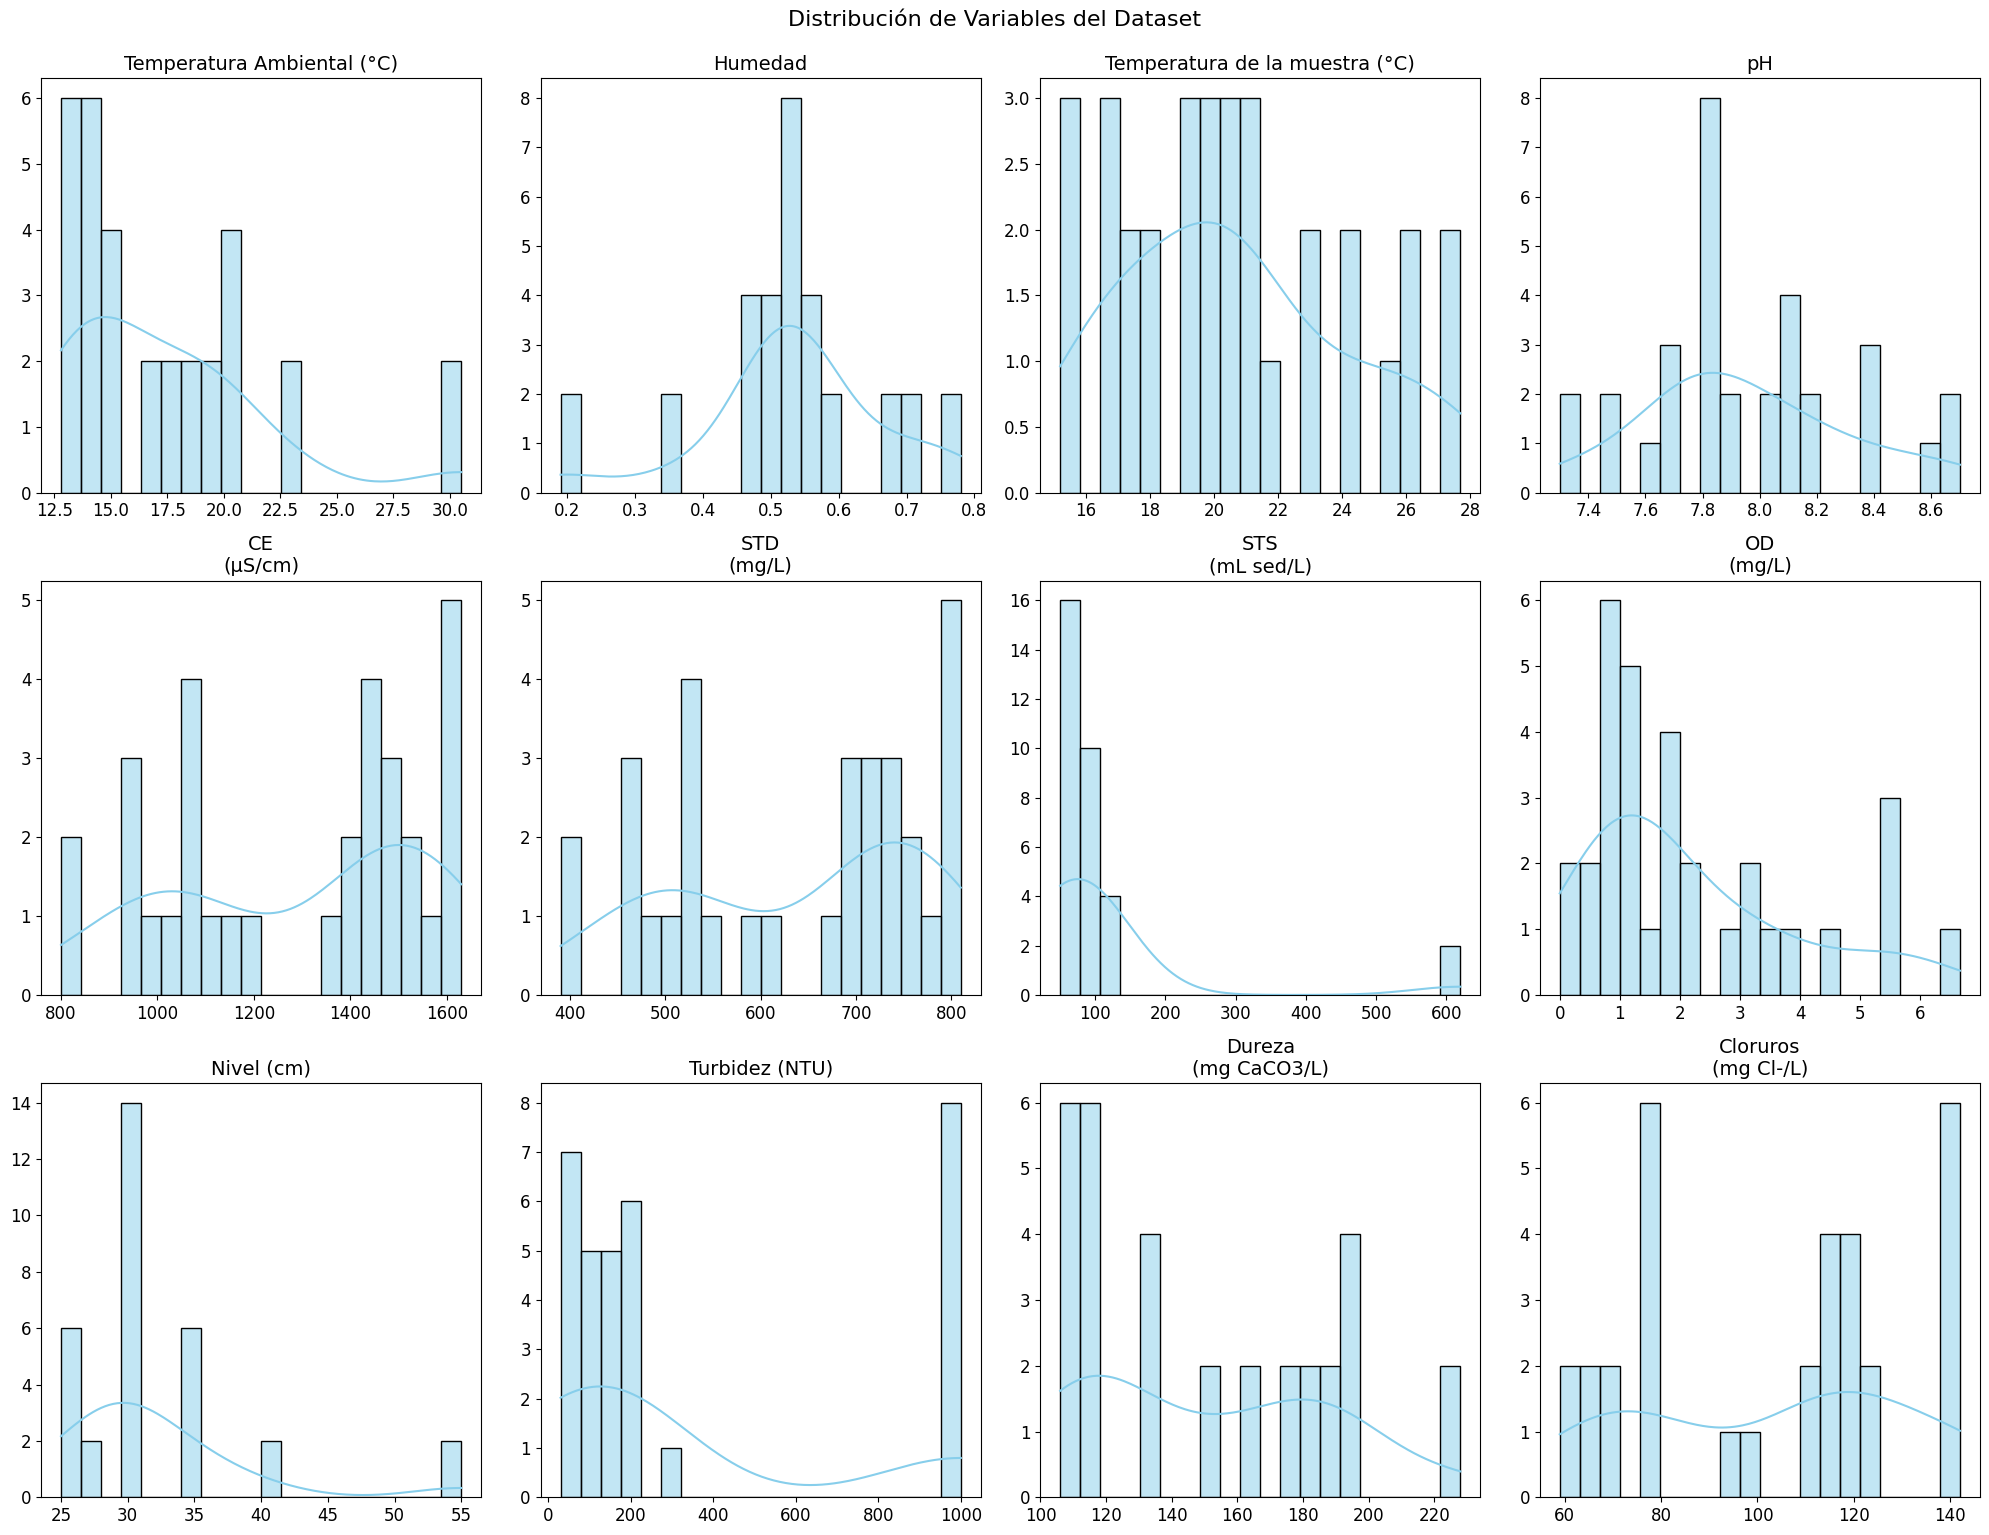

In [7]:

import seaborn as sns
import numpy as np

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del DataFrame
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar el array de ejes para facilitar la indexación
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot adicional
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=20, color='skyblue', kde=True, ax=ax)
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar el diseño
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamar a la función para mostrar los histogramas agrupados
plot_results(df_sin_nulos)


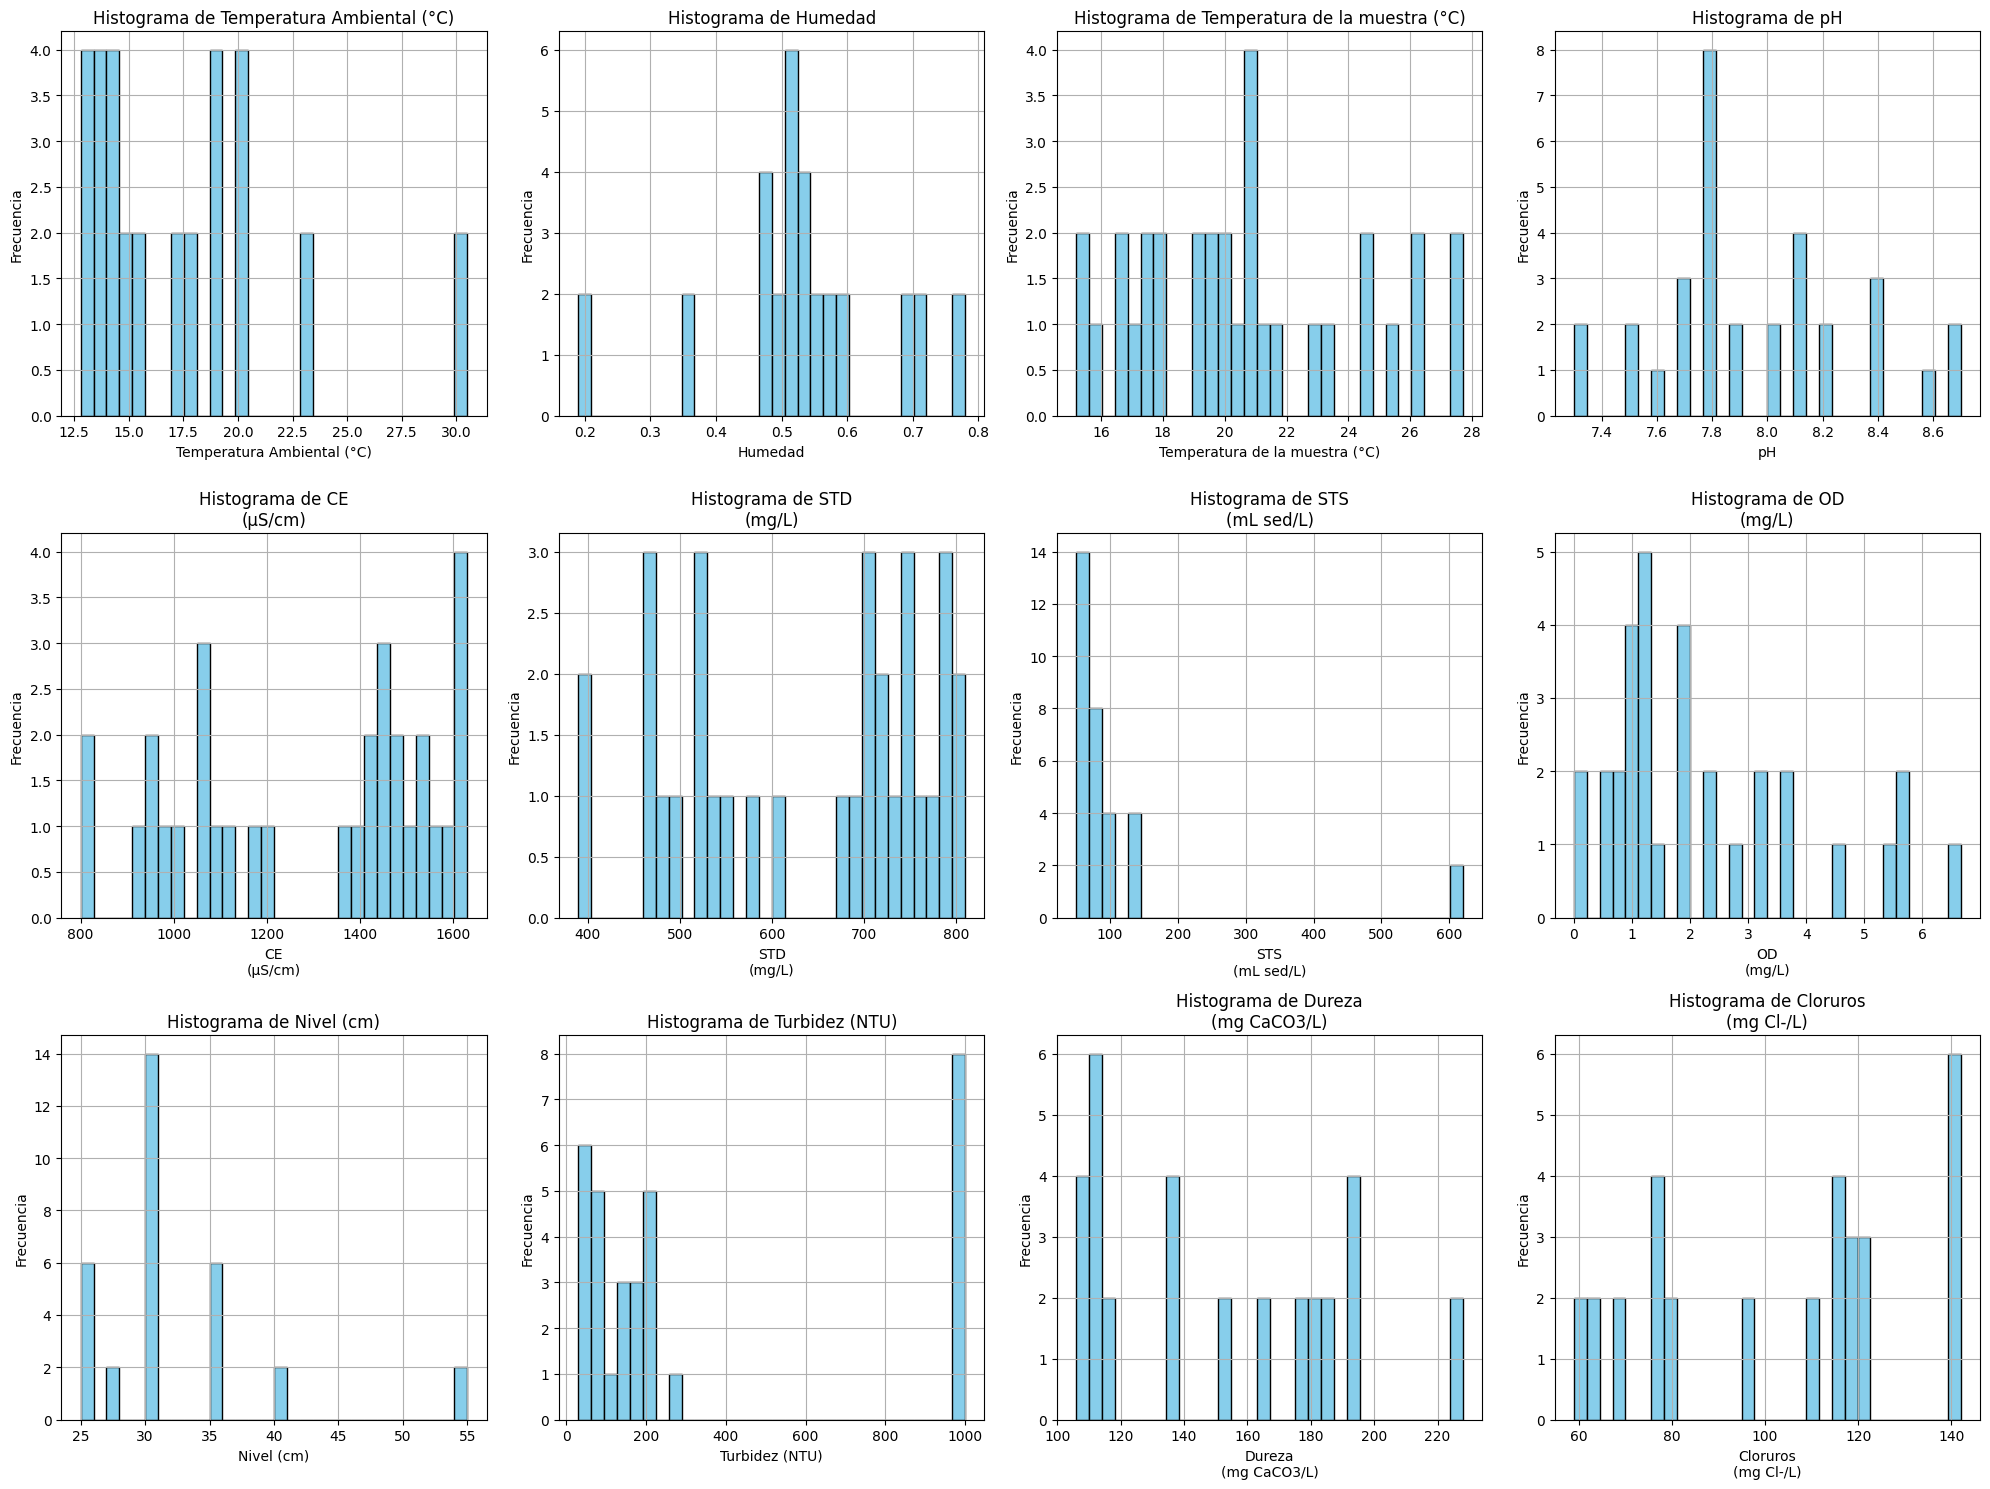

In [8]:

def mostrar_histogramas_agrupados(df):
    # Configuración del tamaño de la figura y el número de subplots
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
    axes = axes.flatten()  # Aplanar la matriz de ejes para un acceso más fácil

    # Iterar sobre las columnas y los ejes
    for i, column in enumerate(df.columns):
        axes[i].hist(df[column], bins=30, edgecolor='black', color='skyblue')
        axes[i].set_title(f'Histograma de {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True)

    # Ajustar el diseño para evitar la superposición de gráficos
    plt.tight_layout()
    plt.show()

# Llamar a la función para mostrar los histogramas agrupados
mostrar_histogramas_agrupados(df_sin_nulos)


In [9]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    median = list()
    std = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
        median.append(dataframe[key].median())
        std.append(dataframe[key].std())
        
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums,
            'median': median,
            'std': std
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),12.80,30.50,16.10,4.555814
1,Humedad,0.19,0.78,0.53,0.135264
2,Temperatura de la muestra (°C),15.20,27.70,20.25,3.567619
3,pH,7.30,8.70,7.85,0.364545
4,CE\n(µS/cm),800.00,1630.00,1405.00,268.867847
5,STD\n(mg/L),390.00,810.00,695.00,133.499728
6,STS\n(mL sed/L),50.00,620.00,77.00,135.959612
7,OD\n(mg/L),0.00,6.66,1.57,1.784927
8,Nivel (cm),25.00,55.00,30.00,7.252294
9,Turbidez (NTU),30.40,1000.00,167.50,388.415016


### Normalización de datos

In [10]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




### Autoencoder basico

In [11]:
from keras.layers import Input, Dense
from keras.activations import sigmoid, tanh
from keras.models import Model
import numpy as np
from tensorflow.keras.callbacks import TensorBoard
import shutil
import os as os

try:
    shutil.rmtree('./.logs')
except FileNotFoundError:
    pass
os.mkdir('./.logs')
vector_size = len(df_sin_nulos.columns)
dataset = np.array(
    normalizer(df_sin_nulos).astype(np.float16)
)
encoded_size = 4

input_layer = Input(shape=(vector_size, )) 

x = Dense(32, activation=sigmoid)(input_layer)
x = Dense(16, activation=sigmoid)(x)

encoded = Dense(encoded_size, activation=sigmoid)(x)
x = Dense(16, activation=sigmoid)(encoded)
x = Dense(32, activation=sigmoid)(x)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_layer, output) # creo un modelo a partir de lo definido arriba
autoencoder.compile(optimizer='adam', loss='mse') # se compila el modelo
autoencoder.summary() # se imprime un resumen


2025-05-09 10:05:00.018085: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-09 10:05:00.059755: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 10:05:00.349552: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-09 10:05:00.352030: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-09 10:05:01.238673: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense (Dense)               (None, 32)                416       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 4)                 68        
                                                                 
 dense_3 (Dense)             (None, 16)                80        
                                                                 
 dense_4 (Dense)             (None, 32)                544       
                                                                 
 dense_5 (Dense)             (None, 12)                396   

## Autoencoder variacional: Un valor entre otros dos valores es correctamente interpolado
### El dataset creado a partir del espacio latente generara valores coherentes.

In [13]:
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras import backend as K
from keras.losses import mean_squared_error
import tensorflow as tf

# Definición de la capa de muestreo
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

###

input_layer = Input(shape=(vector_size,))
encoder_size1 = 24
encoder_size2 = 12
# Encoder
x = Dense(encoder_size1, activation=sigmoid)(input_layer)
x = Dense(encoder_size2, activation=sigmoid)(x)

z_mean = Dense(encoder_size2)(x)
z_log_var = Dense(encoder_size2)(x)

# Capa de muestreo
z = Lambda(sampling, output_shape=(encoder_size2,))([z_mean, z_log_var])

# Decoder
decoder_h1 = Dense(encoder_size2, activation=sigmoid)
decoder_h2 = Dense(encoder_size1, activation=sigmoid)
decoder_output = Dense(vector_size, activation=sigmoid)

x_decoded = decoder_h1(z)
x_decoded = decoder_h2(x_decoded)
x_decoded = decoder_output(x_decoded)

# Modelo completo
vae = Model(input_layer, x_decoded)

# Función de pérdida personalizada
xent_loss = vector_size * mean_squared_error(input_layer, x_decoded)
kl_loss = - 0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
vae_loss = K.mean(xent_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

vae.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense_13 (Dense)            (None, 24)                   312       ['input_3[0][0]']             
                                                                                                  
 dense_14 (Dense)            (None, 12)                   300       ['dense_13[0][0]']            
                                                                                                  
 dense_15 (Dense)            (None, 12)                   156       ['dense_14[0][0]']            
                                                                                            

In [14]:

tensorboard = TensorBoard(log_dir='./.logs') #creo instancia para guardar
epochs = 12000 #20000 cantidad de veces a entranar o pasos para realizar el descenso del gradiente
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=epochs,
    batch_size=len(dataset), #tamaño del bloque de entrenamiento
    shuffle=True,
    verbose=0, # que no envie salidas
    callbacks=[tensorboard]
    
)
    


In [16]:
generator = Model(encoded, output) #va del vector de clasificacion hasta la salida
generator.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_3 (Dense)             (None, 16)                80        
                                                                 
 dense_4 (Dense)             (None, 32)                544       
                                                                 
 dense_5 (Dense)             (None, 12)                396       
                                                                 
Total params: 1020 (3.98 KB)
Trainable params: 1020 (3.98 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
encoder = Model(input_layer, z) #encoded para el basico #va desde el input a los datos codificados o clasificador
encoder.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense_13 (Dense)            (None, 24)                   312       ['input_3[0][0]']             
                                                                                                  
 dense_14 (Dense)            (None, 12)                   300       ['dense_13[0][0]']            
                                                                                                  
 dense_15 (Dense)            (None, 12)                   156       ['dense_14[0][0]']            
                                                                                            

### Generación de Datos Sintéticos

In [18]:
amount = 10000 #cantidad de predicciones
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df.to_csv('./puente_bilbao_redes2.csv')
gen_df

313/313 [==============================] - 0s 615us/step


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,14.785013,0.536273,23.987543,8.101635,1260.344238,628.838318,53.900383,2.712852,27.379507,189.541748,112.039627,110.171700
1,15.862720,0.606158,17.743101,7.940534,1552.986084,765.600769,99.923370,1.137390,26.434151,118.292709,183.475922,127.580811
2,19.244457,0.613694,19.138477,7.540628,1279.373047,637.617859,90.671066,1.312781,25.466671,993.972168,110.947884,111.571671
3,12.578682,0.763492,23.284721,7.492635,877.396240,439.404114,41.049091,2.413841,33.808414,150.398285,109.888824,65.483246
4,20.313730,0.623959,19.113380,7.776165,1523.821411,750.031189,95.391449,1.601638,28.484467,90.183525,194.708298,140.027466
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,18.408749,0.459426,21.186859,8.263678,1415.925537,693.064026,81.853683,3.380451,26.699627,281.876343,142.773315,116.660706
9996,24.210436,0.652885,23.471727,7.714817,1465.806885,720.757935,67.649239,1.774086,30.180141,35.696751,177.473846,141.264511
9997,14.647056,0.475719,19.546247,8.422857,1059.514893,534.174561,81.409843,2.886256,32.448872,58.448650,108.498543,83.648911
9998,18.664669,0.691982,19.809149,7.687646,1537.101318,756.880615,67.494026,2.054829,28.615767,42.924664,196.790726,140.602707


### Histogramas de los datos sintéticos generados

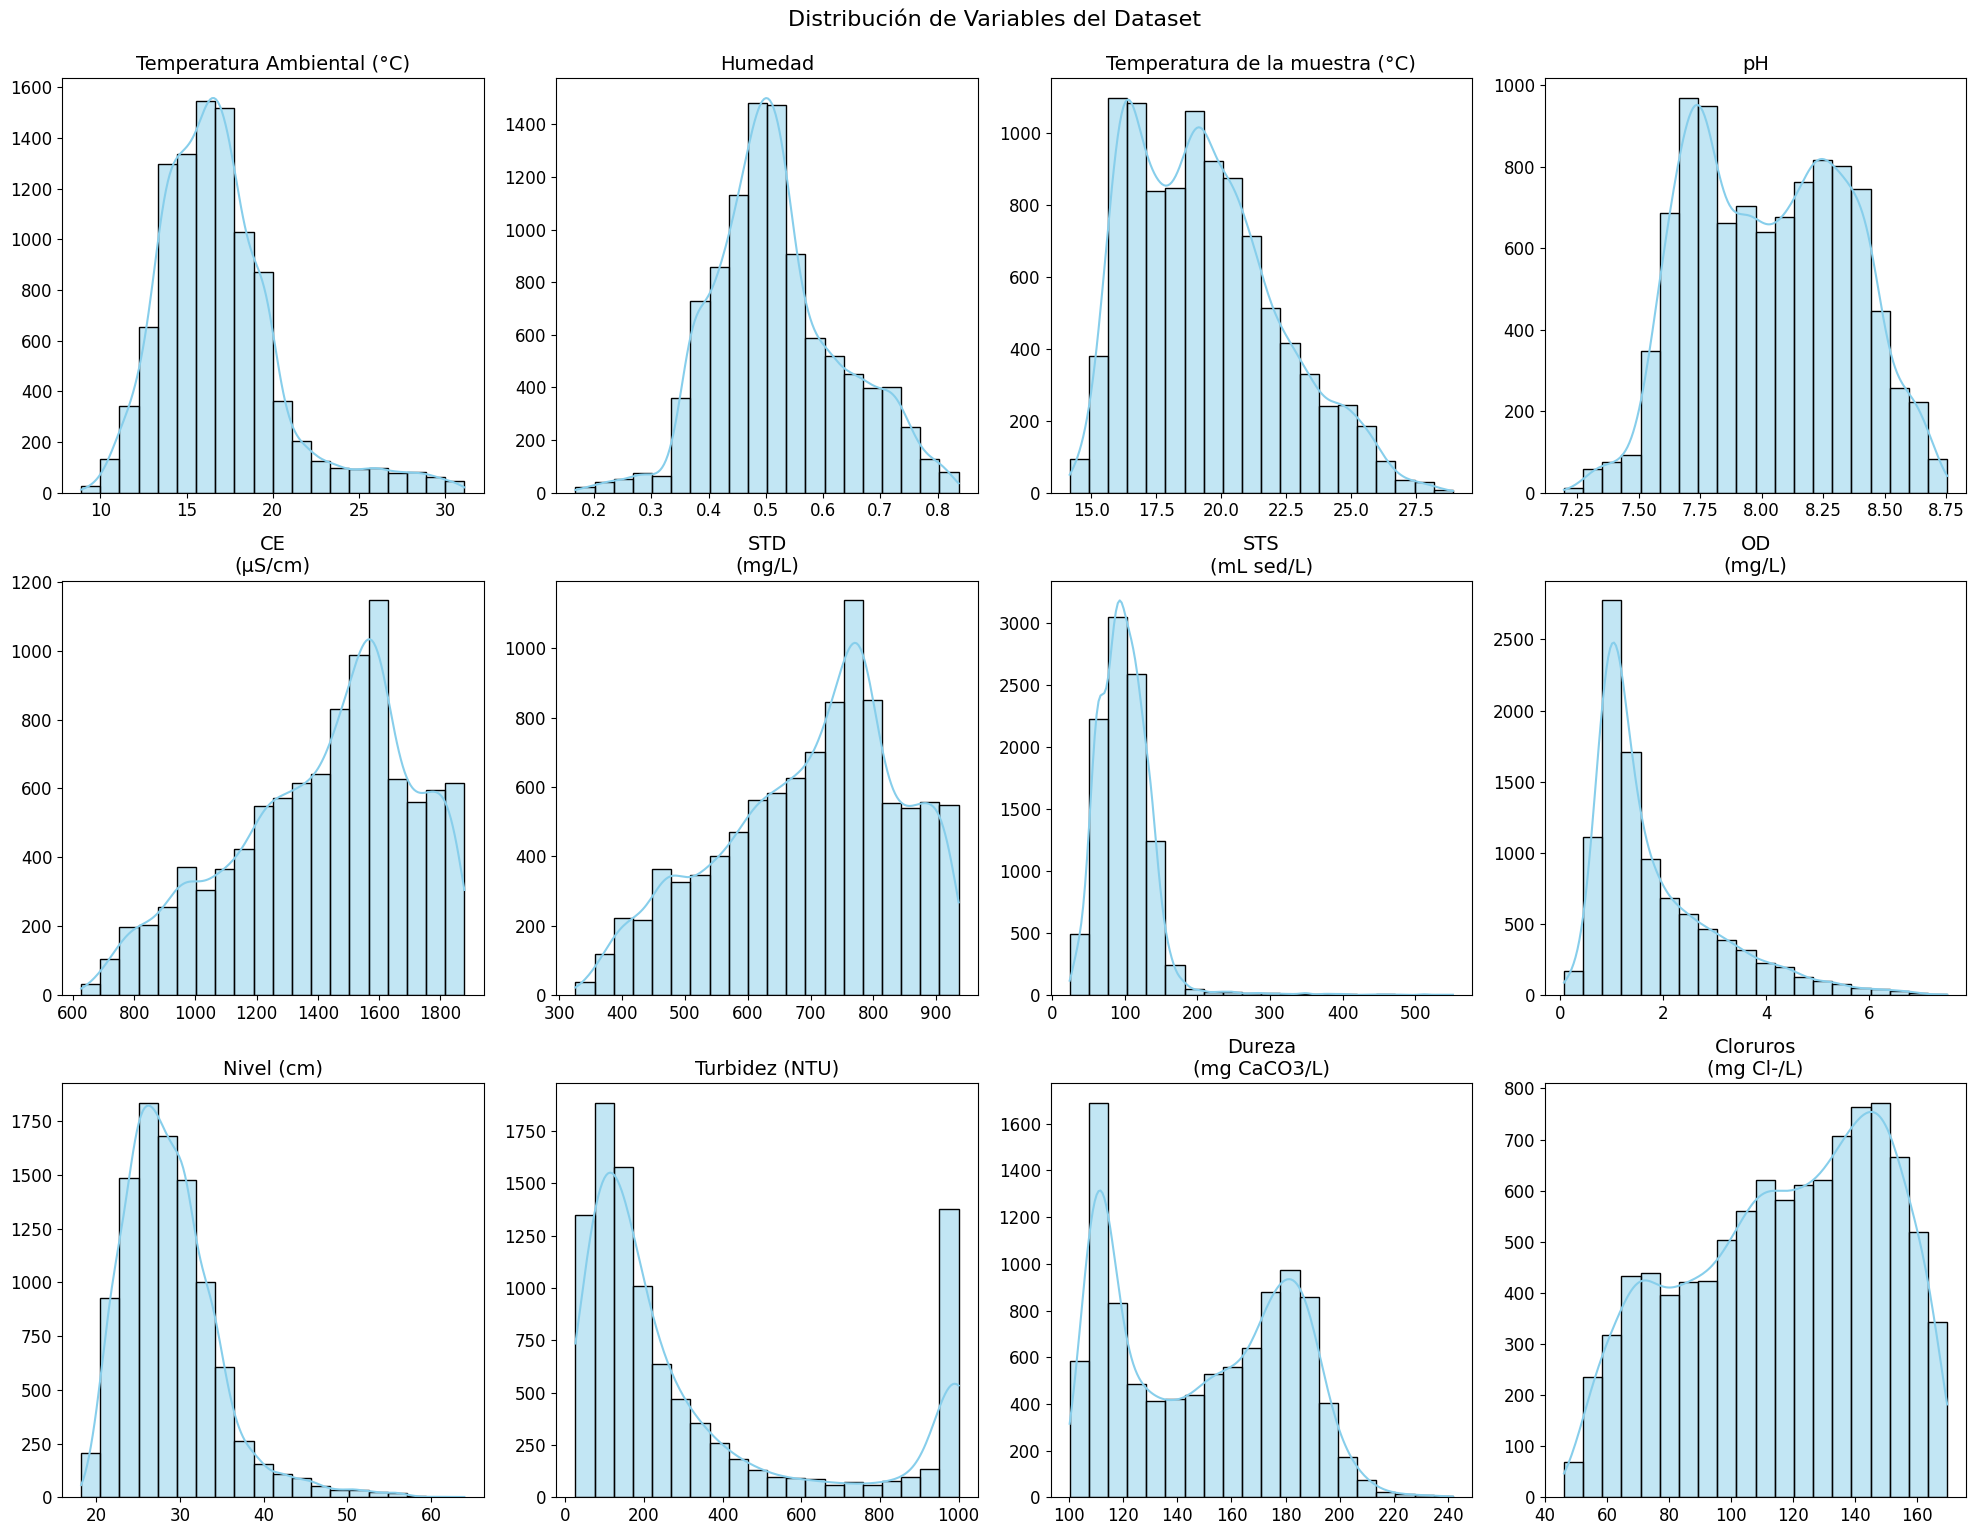

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del dataframe.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar la matriz de ejes para un indexado más fácil
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot sobrante
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=20, color='skyblue', kde=True, ax=ax)  # Ajuste del número de bins a 100
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar la disposición
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamada a la función con el DataFrame generado
plot_results(gen_df)


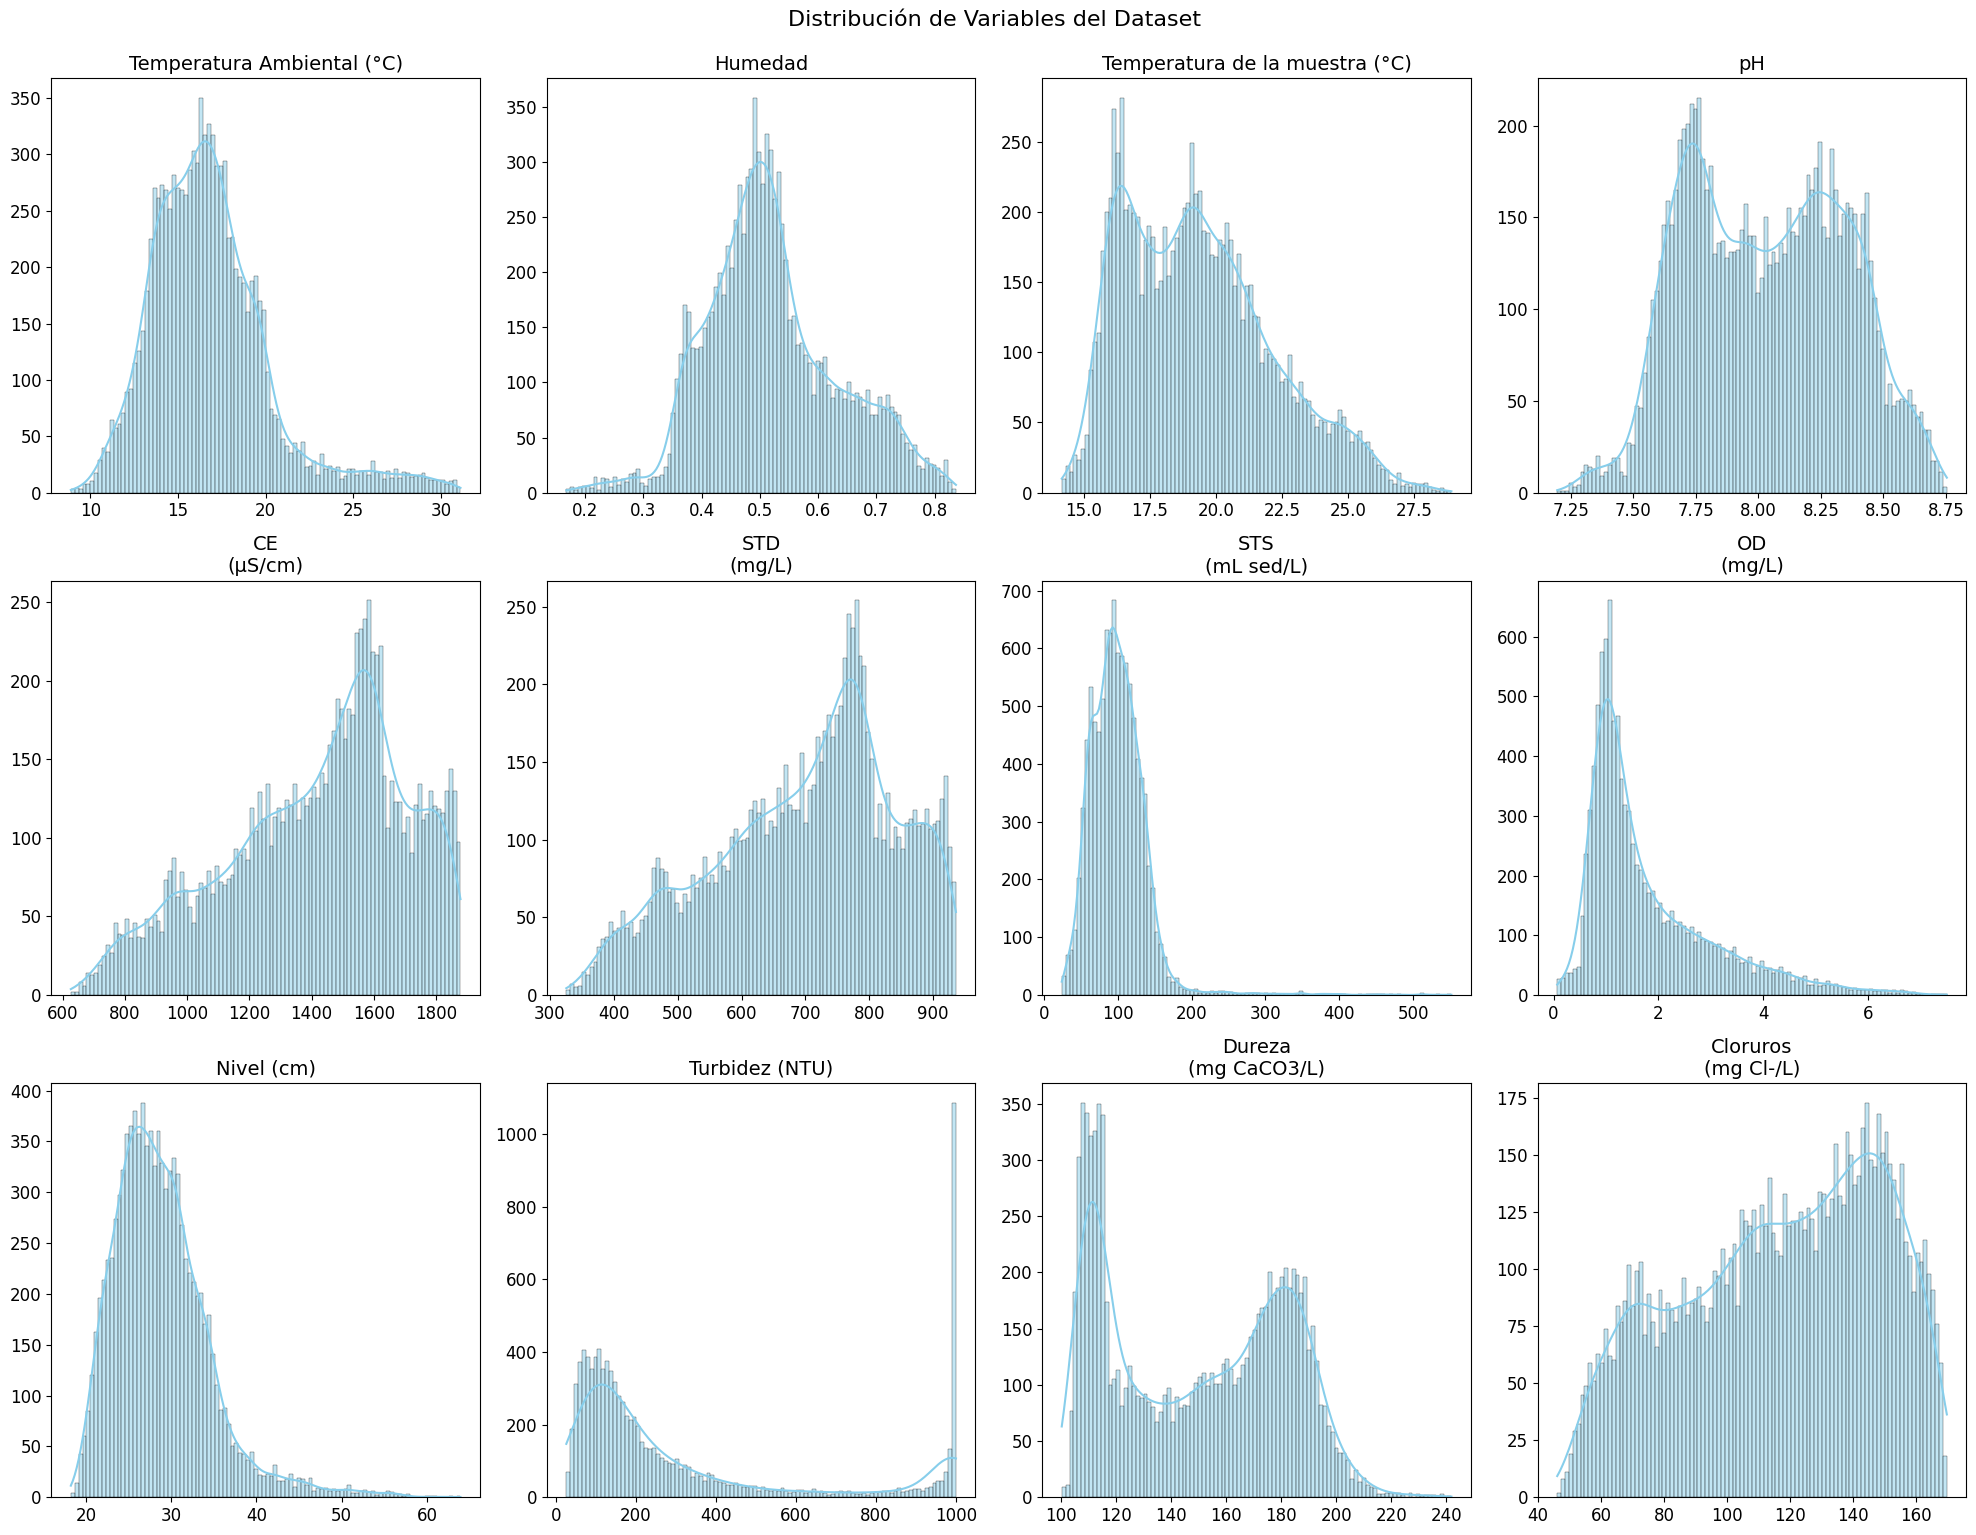

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del dataframe.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar la matriz de ejes para un indexado más fácil
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot sobrante
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=100, color='skyblue', kde=True, ax=ax)  # Ajuste del número de bins a 100
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar la disposición
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamada a la función con el DataFrame generado
plot_results(gen_df)


In [21]:
min_max_info(df_sin_nulos)


,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),12.80,30.50,16.10,4.555814
1,Humedad,0.19,0.78,0.53,0.135264
2,Temperatura de la muestra (°C),15.20,27.70,20.25,3.567619
3,pH,7.30,8.70,7.85,0.364545
4,CE\n(µS/cm),800.00,1630.00,1405.00,268.867847
5,STD\n(mg/L),390.00,810.00,695.00,133.499728
6,STS\n(mL sed/L),50.00,620.00,77.00,135.959612
7,OD\n(mg/L),0.00,6.66,1.57,1.784927
8,Nivel (cm),25.00,55.00,30.00,7.252294
9,Turbidez (NTU),30.40,1000.00,167.50,388.415016


In [22]:
min_max_info(gen_df)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),8.886415,31.117456,16.432226,3.498818
1,Humedad,0.167692,0.836504,0.506877,0.113018
2,Temperatura de la muestra (°C),14.168939,28.918421,19.076075,2.789466
3,pH,7.196379,8.753441,8.031549,0.313859
4,CE\n(µS/cm),626.361755,1878.450928,1470.286865,289.176025
5,STD\n(mg/L),325.692932,935.641785,723.701538,142.138428
6,STS\n(mL sed/L),24.229652,551.834961,96.536667,38.919800
7,OD\n(mg/L),0.069539,7.509162,1.361179,1.218643
8,Nivel (cm),18.239040,63.937057,28.109198,5.719123
9,Turbidez (NTU),25.856867,1000.000000,179.673477,322.452393


In [23]:
colors = encoder.predict(dataset)
color_max = colors.max()
color_min = colors.min()

colored_dataset = df_sin_nulos.copy() #copio el dataset original y lo coloreo con el clsificador (encoder)
#print(colors.shape)


def color_row(row, color_vector):
    #print(color_vector)
    color_vector_normalized = (color_vector - color_min)/(color_max - color_min)
    color_rgb = tuple((color_vector_normalized*255).astype(np.int16))
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_rgb[0], color_rgb[1],255)
    return [f'background-color: {color_hex};' for _ in row.index]

# Create an iterator for the colors
color_iterator = iter(colors)

# Apply colors to each row
styled_df = colored_dataset.style.apply(lambda row: color_row(row, next(color_iterator)), axis=1)
styled_df.to_excel("colored_dataset_variacional.xlsx", engine='openpyxl')


1/1 [==============================] - 0s 60ms/step


ValueError: too many values to unpack (expected 2)

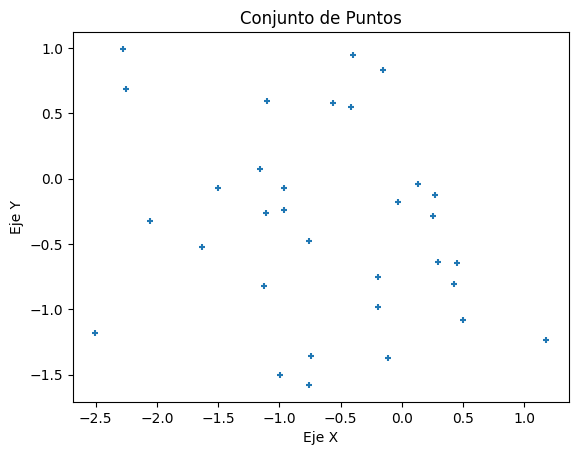

In [24]:
import matplotlib.pyplot as plt


# Dibujamos los puntos
plt.scatter(colors.T[0], colors.T[1], s=20, marker='+')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjunto de Puntos')

# Añadimos índices a cada punto
for i, (xi, yi) in enumerate(colors):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)

plt.show()



### Justificación Matemática

Un Variational Autoencoder (VAE) no solo aprende a mapear los datos a un espacio latente y a reconstruirlos, sino que también trata de hacer que la distribución de esos puntos en el espacio latente siga una distribución normal multivariada, típicamente con media cero y varianza unitaria.

#### ¿Por qué es válido muestrear cerca de la media (0,0) con una cierta desviación estándar?

1. **Distribución Aproximada**: El VAE intenta que la distribución latente \( q(z|x) \) se aproxime a una distribución normal estándar \( p(z) \), donde \( z \) es la variable latente y \( x \) son tus datos. Esto se logra mediante la divergencia KL en la función de pérdida. La Divergencia Kullback-Leibler (KL) es una medida de cuán diferente es una distribución de probabilidad PP con respecto a otra distribución QQ.

2. **Densidad de Probabilidad**: En una distribución normal, la máxima densidad de probabilidad está en la media. Esto significa que los puntos muestreados cerca de la media son, en teoría, "más probables" o "más representativos" del conjunto de datos original.

3. **Varianza Controlada**: Al añadirse un vector de desviación estándar, se esta controlando cuánto nos alejamos de la media. Esto permite muestrear puntos que son plausibles pero que también introducen variabilidad.

#### Cautelas

1. **Interpolación vs Extrapolación**: Muestrear dentro de la "nube" de puntos latentes es generalmente seguro (interpolación). Pero si te alejás demasiado, podés entrar en el terreno de la extrapolación, que es más riesgoso y podría generar puntos no representativos.

2. **Validación**: Sería muy útil validar los puntos generados con expertos en química para asegurarte de que son plausibles.

3. **Estadísticas Descriptivas**: Además, podrían se estadísticas descriptivas y hacer comparaciones gráficas (e.g., histogramas, boxplots) entre los datos originales y los generados para evaluar cuán bien los datos generados representan al conjunto original.


